In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

print("Setup Done ")

Setup Done 


In [ ]:
m, k = 1.0, 10.0
x0, v0 = 1.0, 0.0
t_max, dt = 10.0, 0.01

t = np.arange(0, t_max, dt)
omega = np.sqrt(k/m)

x = x0 * np.cos(omega * t)
v = -x0 * omega * np.sin(omega * t)

kinetic = 0.5 * m * v**2
potential = 0.5 * k * x**2
total_energy = kinetic + potential

print("Energy constant:", total_energy[0])

Energy constant: 5.0


In [ ]:
X = np.stack([x, v], axis=1)[:-1]
y = np.stack([x, v], axis=1)[1:]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(X_train.shape, X_test.shape)

(799, 2) (200, 2)


In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

X_train_t = torch.FloatTensor(X_train_s)
y_train_t = torch.FloatTensor(y_train_s)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True
)

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,2)
        )
    def forward(self,x):
        return self.net(x)

model = Net()
loss_fn = nn.MSELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

Epoch 0, Loss: 0.803532
Epoch 1, Loss: 0.444065
Epoch 2, Loss: 0.160245
Epoch 3, Loss: 0.026505
Epoch 4, Loss: 0.005300
Epoch 5, Loss: 0.001946
Epoch 6, Loss: 0.001017
Epoch 7, Loss: 0.000697
Epoch 8, Loss: 0.000534
Epoch 9, Loss: 0.000422
Epoch 10, Loss: 0.000345
Epoch 11, Loss: 0.000281
Epoch 12, Loss: 0.000234
Epoch 13, Loss: 0.000194
Epoch 14, Loss: 0.000167
Epoch 15, Loss: 0.000144
Epoch 16, Loss: 0.000126
Epoch 17, Loss: 0.000112
Epoch 18, Loss: 0.000099
Epoch 19, Loss: 0.000089


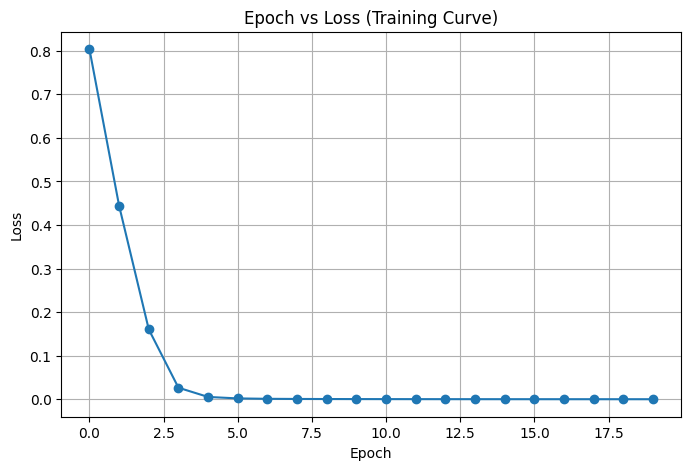

In [ ]:
# Store loss values
losses = []

# Training loop
for epoch in range(20):
    epoch_loss = 0

    for bx, by in train_loader:
        pred = model(bx)
        loss = loss_fn(pred, by)

        opt.zero_grad()
        loss.backward()
        opt.step()

        epoch_loss += loss.item()

    # Average loss
    epoch_loss = epoch_loss / len(train_loader)
    losses.append(epoch_loss)

    # Print every epoch (since only 20 epochs)
    print(f"Epoch {epoch}, Loss: {epoch_loss:.6f}")


# 🔹 Plot Epoch vs Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(20), losses, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss (Training Curve)")

plt.grid(True)
plt.show()

In [ ]:
with torch.no_grad():
    pred = model(torch.FloatTensor(X_test_s)).numpy()

pred = scaler_y.inverse_transform(pred)

mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 0.0002037404251177963
R2: 0.999916036691905


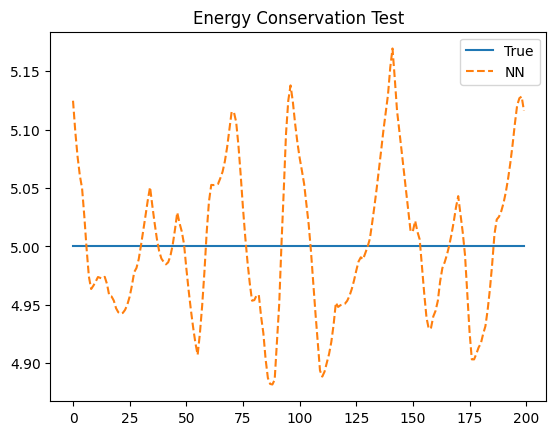

In [ ]:
pred_energy = 0.5*m*pred[:,1]**2 + 0.5*k*pred[:,0]**2
true_energy = total_energy[-len(pred):]

plt.plot(true_energy, label="True")
plt.plot(pred_energy, '--', label="NN")

plt.legend()
plt.title("Energy Conservation Test")
plt.show()

In [ ]:
traj = []
state = X[0]

for _ in range(len(X)):
    s = scaler_X.transform(state.reshape(1,-1))
    s = torch.FloatTensor(s)

    with torch.no_grad():
        nxt = model(s).numpy()

    nxt = scaler_y.inverse_transform(nxt)[0]
    traj.append(nxt)
    state = nxt

traj = np.array(traj)

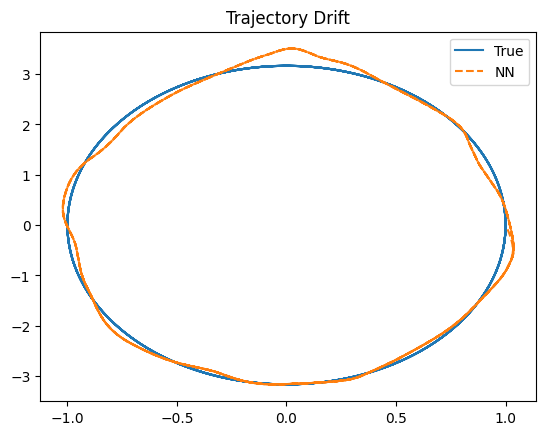

In [ ]:
plt.plot(X[:,0], X[:,1], label="True")
plt.plot(traj[:,0], traj[:,1], '--', label="NN")

plt.legend()
plt.title("Trajectory Drift")
plt.show()

In [ ]:
import pandas as pd

# Create a dataframe
df = pd.DataFrame({
    "time": t,
    "position_x": x,
    "velocity_v": v,
    "kinetic_energy": kinetic,
    "potential_energy": potential,
    "total_energy": total_energy
})

# Save to CSV
df.to_csv("mass_spring_data.csv", index=False)

print("Dataset saved as mass_spring_data.csv")

Dataset saved as mass_spring_data.csv


In [ ]:
from google.colab import files
files.download("mass_spring_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# NEURAL NETWORK vs GROUND TRUTH — Physics Visualizations
# Refactored: Clean, modular, one plot per figure
# ============================================================

import plotly.graph_objects as go
import numpy as np
import torch

# ─────────────────────────────────────────────────────────────
# SHARED THEME HELPERS
# ─────────────────────────────────────────────────────────────

DARK_BG      = "rgba(10, 10, 18, 1)"
PANEL_BG     = "rgba(18, 18, 30, 1)"
GRID_COLOR   = "rgba(255, 255, 255, 0.07)"
FONT_COLOR   = "#E8E8F0"
ACCENT_CYAN  = "#00E5FF"
ACCENT_ORANGE= "#FF6D00"
ACCENT_GREEN = "#69FF47"
ACCENT_PINK  = "#FF4081"
ACCENT_GOLD  = "#FFD740"

FONT_FAMILY  = "IBM Plex Mono, monospace"


def base_layout(title: str, width: int = 1000, height: int = 650) -> dict:
    """Returns a consistent dark-theme layout dict."""
    return dict(
        title=dict(
            text=title,
            font=dict(family=FONT_FAMILY, size=17, color=FONT_COLOR),
            x=0.04, xanchor="left",
        ),
        paper_bgcolor=DARK_BG,
        plot_bgcolor=PANEL_BG,
        font=dict(family=FONT_FAMILY, color=FONT_COLOR, size=11),
        width=width,
        height=height,
        margin=dict(l=60, r=40, t=70, b=60),
        legend=dict(
            bgcolor="rgba(255,255,255,0.05)",
            bordercolor="rgba(255,255,255,0.12)",
            borderwidth=1,
            font=dict(size=11),
        ),
    )


def styled_axis(title: str) -> dict:
    return dict(
        title=dict(text=title, font=dict(size=12, color=FONT_COLOR)),
        gridcolor=GRID_COLOR,
        linecolor="rgba(255,255,255,0.15)",
        tickfont=dict(size=10),
        zeroline=False,
    )


def styled_3d_axis(title: str) -> dict:
    return dict(
        title=dict(text=title, font=dict(size=11)),
        gridcolor=GRID_COLOR,
        backgroundcolor="rgba(0,0,0,0)",
        showbackground=True,
        tickfont=dict(size=9),
    )


# ─────────────────────────────────────────────────────────────
# PREDICTION GENERATOR
# ─────────────────────────────────────────────────────────────

def generate_prediction_trajectory(model, scaler_X, scaler_y, X_initial, n_steps):
    """Autoregressively roll out NN predictions for n_steps."""
    model.eval()
    traj = []
    state = X_initial.copy()
    with torch.no_grad():
        for _ in range(n_steps):
            state_scaled = scaler_X.transform(state.reshape(1, -1))
            state_tensor  = torch.FloatTensor(state_scaled)
            next_scaled   = model(state_tensor).numpy()
            next_state    = scaler_y.inverse_transform(next_scaled).flatten()
            traj.append(next_state)
            state = next_state
    return np.array(traj)


# ─────────────────────────────────────────────────────────────
# SETUP  (runs once; skips if variables already exist)
# ─────────────────────────────────────────────────────────────

if "pred_traj" not in dir():
    pred_traj = generate_prediction_trajectory(
        model, scaler_X, scaler_y, X[0], n_steps=len(X)
    )

t_pred    = t[1 : len(pred_traj) + 1]
pred_pos  = pred_traj[:, 0]
pred_vel  = pred_traj[:, 1]

# Energies
pred_kinetic   = 0.5 * m * pred_vel  ** 2
pred_potential = 0.5 * k * pred_pos  ** 2
pred_total     = pred_kinetic + pred_potential

n = len(t_pred)
true_kinetic   = kinetic[1 : n + 1]
true_potential = potential[1 : n + 1]
true_total     = total_energy[1 : n + 1]

energy_error   = true_total - pred_total


# ═══════════════════════════════════════════════════════════════
# PLOT 1 — Ground Truth: 3D Phase Space  (Time × Position × Velocity)
# ═══════════════════════════════════════════════════════════════

fig1 = go.Figure()

fig1.add_trace(go.Scatter3d(
    x=t, y=x, z=v,
    mode="lines",
    line=dict(color=ACCENT_CYAN, width=3),
    name="Trajectory",
))
fig1.add_trace(go.Scatter3d(
    x=t[::15], y=x[::15], z=v[::15],
    mode="markers",
    marker=dict(
        size=3,
        color=t[::15],
        colorscale="Turbo",
        showscale=True,
        colorbar=dict(title=dict(text="Time (s)", font=dict(size=11)), x=0.9, thickness=12),
    ),
    name="Time-coloured markers",
))
fig1.add_trace(go.Scatter3d(
    x=[t[0]], y=[x[0]], z=[v[0]],
    mode="markers",
    marker=dict(size=9, color=ACCENT_GREEN, symbol="circle"),
    name="t = 0  (start)",
))
fig1.add_trace(go.Scatter3d(
    x=[t[-1]], y=[x[-1]], z=[v[-1]],
    mode="markers",
    marker=dict(size=9, color=ACCENT_PINK, symbol="x"),
    name="t = T  (end)",
))

fig1.update_layout(
    **base_layout("GROUND TRUTH — 3D Phase Space (Time → Position → Velocity)", height=700),
    scene=dict(
        xaxis=styled_3d_axis("Time (s)"),
        yaxis=styled_3d_axis("Position (m)"),
        zaxis=styled_3d_axis("Velocity (m/s)"),
        camera=dict(eye=dict(x=2.0, y=2.0, z=1.4)),
        bgcolor="rgba(0,0,0,0)",
    ),
)
fig1.show()


# # ═══════════════════════════════════════════════════════════════
# # PLOT 2 — Potential Energy Surface with Ground-Truth Path
# # ═══════════════════════════════════════════════════════════════

# x_grid = np.linspace(x.min(), x.max(), 100)
# t_grid = np.linspace(t.min(), t.max(), 100)
# Xg, Tg = np.meshgrid(x_grid, t_grid)
# Ug     = 0.5 * k * Xg ** 2

# fig2 = go.Figure()
# fig2.add_trace(go.Surface(
#     x=Tg, y=Xg, z=Ug,
#     colorscale="Plasma",
#     opacity=0.75,
#     showscale=True,
#     colorbar=dict(title=dict(text="PE (J)", font=dict(size=11)), x=0.9, thickness=12),
#     name="Potential Surface",
# ))
# fig2.add_trace(go.Scatter3d(
#     x=t, y=x, z=true_potential[: len(t)] if len(true_potential) >= len(t) else potential,
#     mode="lines",
#     line=dict(color=ACCENT_PINK, width=5),
#     name="System Path",
# ))

# fig2.update_layout(
#     **base_layout("POTENTIAL ENERGY SURFACE — Parabolic Well with System Path", height=700),
#     scene=dict(
#         xaxis=styled_3d_axis("Time (s)"),
#         yaxis=styled_3d_axis("Position (m)"),
#         zaxis=styled_3d_axis("Potential Energy (J)"),
#         camera=dict(eye=dict(x=1.6, y=1.6, z=1.2)),
#         bgcolor="rgba(0,0,0,0)",
#     ),
# )
# fig2.show()


# ═══════════════════════════════════════════════════════════════
# PLOT 3 — 3D Phase Space: Ground Truth vs NN Prediction
# ═══════════════════════════════════════════════════════════════

fig3 = go.Figure()
fig3.add_trace(go.Scatter3d(
    x=t, y=x, z=v,
    mode="lines",
    line=dict(color=ACCENT_CYAN, width=4),
    name="Ground Truth",
))
fig3.add_trace(go.Scatter3d(
    x=t_pred, y=pred_pos, z=pred_vel,
    mode="lines",
    line=dict(color=ACCENT_ORANGE, width=4),
    name="NN Prediction",
))

fig3.update_layout(
    **base_layout("PHASE SPACE COMPARISON — Ground Truth vs NN Prediction", height=700),
    scene=dict(
        xaxis=styled_3d_axis("Time (s)"),
        yaxis=styled_3d_axis("Position (m)"),
        zaxis=styled_3d_axis("Velocity (m/s)"),
        camera=dict(eye=dict(x=2.0, y=2.0, z=1.4)),
        bgcolor="rgba(0,0,0,0)",
    ),
)
fig3.show()


# # ═══════════════════════════════════════════════════════════════
# # PLOT 4 — Energy Comparison: All 3 Energy Types Side-by-Side
# # ═══════════════════════════════════════════════════════════════

# fig4 = go.Figure()

# # ── Kinetic ──────────────────────────────────────────────────
# fig4.add_trace(go.Scatter(
#     x=t_pred, y=true_kinetic,
#     mode="lines",
#     line=dict(color=ACCENT_CYAN, width=2.5),
#     name="True  — Kinetic",
#     legendgroup="kinetic",
# ))
# fig4.add_trace(go.Scatter(
#     x=t_pred, y=pred_kinetic,
#     mode="lines",
#     line=dict(color=ACCENT_CYAN, width=2, dash="dot"),
#     name="Pred  — Kinetic",
#     legendgroup="kinetic",
# ))

# # ── Potential ─────────────────────────────────────────────────
# fig4.add_trace(go.Scatter(
#     x=t_pred, y=true_potential,
#     mode="lines",
#     line=dict(color=ACCENT_PINK, width=2.5),
#     name="True  — Potential",
#     legendgroup="potential",
# ))
# fig4.add_trace(go.Scatter(
#     x=t_pred, y=pred_potential,
#     mode="lines",
#     line=dict(color=ACCENT_PINK, width=2, dash="dot"),
#     name="Pred  — Potential",
#     legendgroup="potential",
# ))

# # ── Total ────────────────────────────────────────────────────
# fig4.add_trace(go.Scatter(
#     x=t_pred, y=true_total,
#     mode="lines",
#     line=dict(color=ACCENT_GOLD, width=3),
#     name="True  — Total",
#     legendgroup="total",
# ))
# fig4.add_trace(go.Scatter(
#     x=t_pred, y=pred_total,
#     mode="lines",
#     line=dict(color=ACCENT_GOLD, width=2.5, dash="dot"),
#     name="Pred  — Total",
#     legendgroup="total",
# ))

# fig4.update_layout(
#     **base_layout("ENERGY BREAKDOWN — Ground Truth (solid) vs NN Prediction (dotted)"),
#     xaxis=styled_axis("Time (s)"),
#     yaxis=styled_axis("Energy (J)"),
# )
# fig4.show()


# ═══════════════════════════════════════════════════════════════
# PLOT 5 — Total Energy Conservation: True vs Predicted
# ═══════════════════════════════════════════════════════════════

fig5 = go.Figure()

fig5.add_trace(go.Scatter(
    x=t_pred, y=true_total,
    mode="lines",
    line=dict(color=ACCENT_CYAN, width=3),
    fill="tozeroy",
    fillcolor="rgba(0,229,255,0.08)",
    name="True Total Energy",
))
fig5.add_trace(go.Scatter(
    x=t_pred, y=pred_total,
    mode="lines",
    line=dict(color=ACCENT_ORANGE, width=2.5, dash="dash"),
    name="Predicted Total Energy",
))

fig5.update_layout(
    **base_layout("ENERGY CONSERVATION — True vs Predicted Total Energy"),
    xaxis=styled_axis("Time (s)"),
    yaxis=styled_axis("Total Energy (J)"),
)
fig5.show()


# ═══════════════════════════════════════════════════════════════
# PLOT 6 — Energy Prediction Error Over Time
# ═══════════════════════════════════════════════════════════════

# fig6 = go.Figure()

# fig6.add_hrect(
#     y0=-0.05 * abs(energy_error).max(),
#     y1= 0.05 * abs(energy_error).max(),
#     fillcolor="rgba(255,215,64,0.07)",
#     line_width=0,
#     annotation_text="±5 % tolerance",
#     annotation_font=dict(size=10, color=ACCENT_GOLD),
# )
# fig6.add_trace(go.Scatter(
#     x=t_pred, y=energy_error,
#     mode="lines+markers",
#     line=dict(color=ACCENT_ORANGE, width=2),
#     marker=dict(
#         size=4,
#         color=energy_error,
#         colorscale="RdYlGn",
#         showscale=True,
#         colorbar=dict(title=dict(text="Error (J)", font=dict(size=11)), thickness=12),
#     ),
#     name="Energy Error",
# ))
# fig6.add_hline(y=0, line_dash="dash", line_color="rgba(255,255,255,0.3)", line_width=1)

# fig6.update_layout(
#     **base_layout("ENERGY PREDICTION ERROR — True − Predicted"),
#     xaxis=styled_axis("Time (s)"),
#     yaxis=styled_axis("Error (J)"),
# )
# fig6.show()


# ═══════════════════════════════════════════════════════════════
# PLOT 7 — 3D Energy Map: Position–Velocity–Energy (GT vs Pred)
# ═══════════════════════════════════════════════════════════════

fig7 = go.Figure()

fig7.add_trace(go.Scatter3d(
    x=x[1 : n + 1], y=v[1 : n + 1], z=true_total,
    mode="lines",
    line=dict(color=ACCENT_CYAN, width=4),
    name="Ground Truth",
))
fig7.add_trace(go.Scatter3d(
    x=pred_pos, y=pred_vel, z=pred_total,
    mode="lines",
    line=dict(color=ACCENT_ORANGE, width=4),
    name="NN Prediction",
))

fig7.update_layout(
    **base_layout("3D ENERGY MAP — Position × Velocity × Total Energy", height=700),
    scene=dict(
        xaxis=styled_3d_axis("Position (m)"),
        yaxis=styled_3d_axis("Velocity (m/s)"),
        zaxis=styled_3d_axis("Total Energy (J)"),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
        bgcolor="rgba(0,0,0,0)",
    ),
)
fig7.show()


# ─────────────────────────────────────────────────────────────
print("\n  All  plots rendered successfully.")
print("   Use mouse to rotate, zoom, and pan any 3D figure.")


  All  plots rendered successfully.
   Use mouse to rotate, zoom, and pan any 3D figure.


In [ ]:
# ============================================================
# HNN - DATA PREPARATION  (800 train / 200 test)
# Reuses x, v, t, dt, m, k already in memory from NN section
# ============================================================

# Central-difference derivatives of the full trajectory
dqdt_np = np.gradient(x, dt)          # ≈  v    → dq/dt = ∂H/∂p
dpdt_np = np.gradient(v, dt)          # ≈ -k*x  → dp/dt = -∂H/∂q

# Full phase-space arrays
qp_np  = np.stack([x, v],               axis=1).astype(np.float32)  # (1000, 2)
dqp_np = np.stack([dqdt_np, dpdt_np],   axis=1).astype(np.float32)  # (1000, 2)

# ── Train / Test split  (no shuffle, same style as NN above) ──
split = 800

qp_train,  qp_test  = qp_np[:split],  qp_np[split:]      # (800,2) / (200,2)
dqp_train, dqp_test = dqp_np[:split], dqp_np[split:]

# Convert to tensors
qp_train_t  = torch.FloatTensor(qp_train)
dqp_train_t = torch.FloatTensor(dqp_train)
qp_test_t   = torch.FloatTensor(qp_test)
dqp_test_t  = torch.FloatTensor(dqp_test)

print("HNN Data Split:")
print(f"  Train : {qp_train_t.shape}  (inputs)  |  {dqp_train_t.shape}  (targets)")
print(f"  Test  : {qp_test_t.shape}  (inputs)  |  {dqp_test_t.shape}  (targets)")

HNN Data Split:
  Train : torch.Size([800, 2])  (inputs)  |  torch.Size([800, 2])  (targets)
  Test  : torch.Size([200, 2])  (inputs)  |  torch.Size([200, 2])  (targets)


In [ ]:
# ============================================================
# HNN - MODEL DEFINITION
# ============================================================
# Normal NN  →  learns  f(q,p) → (q_next, p_next)  directly.
#                 Nothing stops it from violating energy conservation.
#
# HNN        →  learns a scalar  H(q,p)  (the Hamiltonian).
#                 Dynamics are derived via autograd:
#                     dq/dt =  ∂H/∂p
#                     dp/dt = -∂H/∂q
#                 Hamilton's equations GUARANTEE energy conservation
#                 by construction — the network cannot break it.
# ============================================================

class HNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)       # single scalar output: H(q,p)
        )

    def forward(self, qp):
        return self.net(qp)                # returns H(q,p)

    def time_derivative(self, qp):
        """
        Computes (dq/dt, dp/dt) from H(q,p) using autograd.
        No physics equation is hard-coded — the network learns it.
        """
        qp = qp.clone().requires_grad_(True)
        H  = self.forward(qp).sum()

        # Gradients: ∂H/∂q and ∂H/∂p
        grad = torch.autograd.grad(H, qp, create_graph=True)[0]
        dHdq = grad[:, 0]
        dHdp = grad[:, 1]

        # Hamilton's equations
        dqdt =  dHdp      # dq/dt =  ∂H/∂p
        dpdt = -dHdq      # dp/dt = -∂H/∂q

        return torch.stack([dqdt, dpdt], dim=1)


hnn_model = HNN(hidden_dim=64)
hnn_opt   = optim.Adam(hnn_model.parameters(), lr=1e-3)

print("HNN Architecture:")
print(hnn_model)
total_params = sum(p.numel() for p in hnn_model.parameters())
print(f"\nTotal trainable parameters: {total_params}")

HNN Architecture:
HNN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 4417


Epoch  400/2000  |  Train Loss: 0.002804  |  Test Loss:  0.002787
Epoch  800/2000  |  Train Loss: 0.000190  |  Test Loss:  0.000187
Epoch 1200/2000  |  Train Loss: 0.000078  |  Test Loss:  0.000078
Epoch 1600/2000  |  Train Loss: 0.000043  |  Test Loss:  0.000044
Epoch 2000/2000  |  Train Loss: 0.000024  |  Test Loss:  0.000028

Training Complete.
Final Train Loss : 0.000024
Final Test  Loss : 0.000028


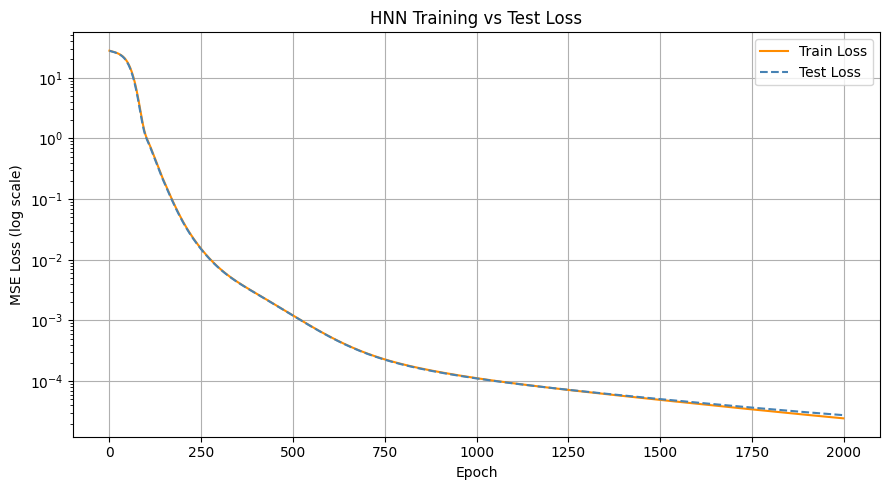

In [ ]:
# ============================================================
# HNN - TRAINING  (on 800 training points)
# ============================================================

hnn_train_losses = []
hnn_test_losses  = []
EPOCHS = 2000

for epoch in range(EPOCHS):
    # ── Training step ──────────────────────────────────────
    hnn_model.train()
    pred_train = hnn_model.time_derivative(qp_train_t)
    train_loss = ((pred_train - dqp_train_t) ** 2).mean()

    hnn_opt.zero_grad()
    train_loss.backward()
    hnn_opt.step()

    # ── Evaluation on test set (no gradient) ───────────────
    hnn_model.eval()
    with torch.no_grad():
        # For test loss we use a fresh forward pass without autograd graph
        # so we temporarily enable grad just for time_derivative
        pass

    # test loss needs enable_grad for autograd inside time_derivative
    pred_test = hnn_model.time_derivative(qp_test_t)
    test_loss = ((pred_test - dqp_test_t) ** 2).mean()

    hnn_train_losses.append(train_loss.item())
    hnn_test_losses.append(test_loss.item())

    if (epoch + 1) % 400 == 0:
        print(f"Epoch {epoch+1:4d}/{EPOCHS}  |  "
              f"Train Loss: {train_loss.item():.6f}  |  "
              f"Test Loss:  {test_loss.item():.6f}")

print("\nTraining Complete.")
print(f"Final Train Loss : {hnn_train_losses[-1]:.6f}")
print(f"Final Test  Loss : {hnn_test_losses[-1]:.6f}")

# ── Training vs Validation Loss Curve ──────────────────────
plt.figure(figsize=(9, 5))
plt.plot(hnn_train_losses, label="Train Loss", color='darkorange')
plt.plot(hnn_test_losses,  label="Test Loss",  color='steelblue', linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("HNN Training vs Test Loss")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

   HNN TEST SET METRICS  (200 test points)
  dq/dt  →  MSE: 0.000046  |  MAE: 0.005374  |  R²: 0.999991
  dp/dt  →  MSE: 0.000009  |  MAE: 0.001959  |  R²: 1.000000


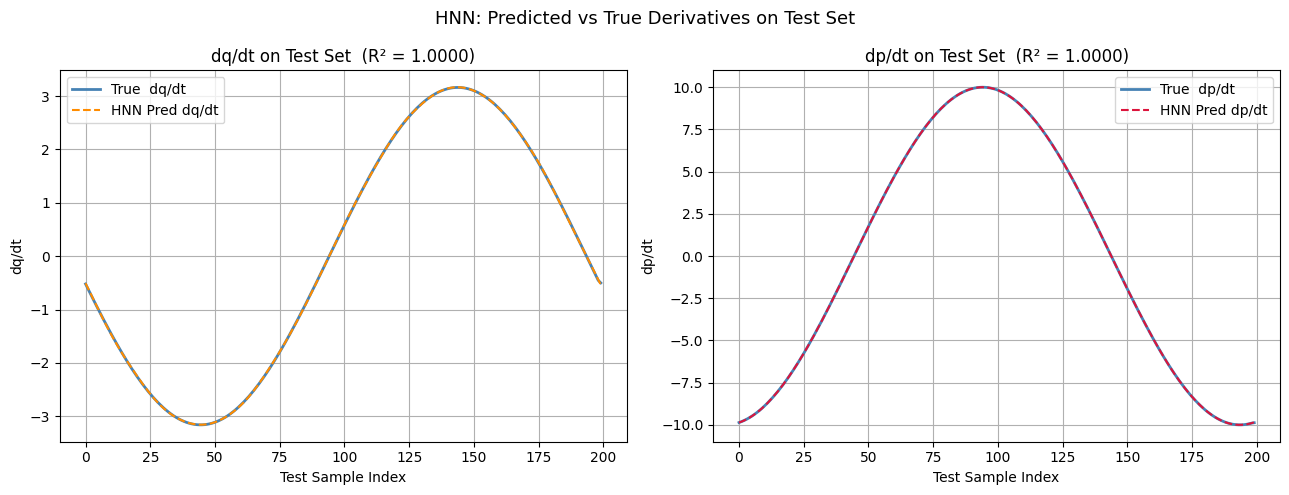

In [ ]:
# ============================================================
# HNN - TEST SET EVALUATION
# ============================================================
# We evaluate how well the HNN predicts dq/dt and dp/dt
# on the 200 unseen test points.
# ============================================================

hnn_model.eval()
pred_test_deriv = hnn_model.time_derivative(qp_test_t).detach().numpy()
true_test_deriv = dqp_test.copy()

# Metrics on dq/dt  (position derivative)
mse_dqdt = mean_squared_error(true_test_deriv[:, 0], pred_test_deriv[:, 0])
r2_dqdt  = r2_score(true_test_deriv[:, 0],           pred_test_deriv[:, 0])
mae_dqdt = mean_absolute_error(true_test_deriv[:, 0], pred_test_deriv[:, 0])

# Metrics on dp/dt  (momentum derivative)
mse_dpdt = mean_squared_error(true_test_deriv[:, 1], pred_test_deriv[:, 1])
r2_dpdt  = r2_score(true_test_deriv[:, 1],           pred_test_deriv[:, 1])
mae_dpdt = mean_absolute_error(true_test_deriv[:, 1], pred_test_deriv[:, 1])

print("=" * 45)
print("   HNN TEST SET METRICS  (200 test points)")
print("=" * 45)
print(f"  dq/dt  →  MSE: {mse_dqdt:.6f}  |  MAE: {mae_dqdt:.6f}  |  R²: {r2_dqdt:.6f}")
print(f"  dp/dt  →  MSE: {mse_dpdt:.6f}  |  MAE: {mae_dpdt:.6f}  |  R²: {r2_dpdt:.6f}")
print("=" * 45)

# ── Predicted vs True Derivatives on Test Set ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(true_test_deriv[:, 0], label="True  dq/dt", linewidth=2, color='steelblue')
axes[0].plot(pred_test_deriv[:, 0], '--', label="HNN Pred dq/dt", color='darkorange')
axes[0].set_title(f"dq/dt on Test Set  (R² = {r2_dqdt:.4f})")
axes[0].set_xlabel("Test Sample Index")
axes[0].set_ylabel("dq/dt")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(true_test_deriv[:, 1], label="True  dp/dt", linewidth=2, color='steelblue')
axes[1].plot(pred_test_deriv[:, 1], '--', label="HNN Pred dp/dt", color='crimson')
axes[1].set_title(f"dp/dt on Test Set  (R² = {r2_dpdt:.4f})")
axes[1].set_xlabel("Test Sample Index")
axes[1].set_ylabel("dp/dt")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("HNN: Predicted vs True Derivatives on Test Set", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# HNN - TRAJECTORY ROLLOUT  using RK4 + learned Hamiltonian
# ============================================================
# Two rollouts:
#   (a) starting from the training region  → compare with NN traj
#   (b) starting from the test region start point (index 800)
# ============================================================

def hnn_rk4_step(model, state_np, dt):
    """One RK4 integration step using HNN-derived derivatives."""
    def deriv(s):
        s_t = torch.FloatTensor(s).unsqueeze(0)
        with torch.enable_grad():
            d = model.time_derivative(s_t)
        return d.detach().numpy()[0]

    k1 = deriv(state_np)
    k2 = deriv(state_np + 0.5 * dt * k1)
    k3 = deriv(state_np + 0.5 * dt * k2)
    k4 = deriv(state_np + dt * k3)
    return state_np + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


# ── (a) Full rollout from t=0  (same start as NN) ───────────
hnn_traj_full = [qp_np[0].copy()]
state = qp_np[0].copy()
for _ in range(len(qp_np) - 1):
    state = hnn_rk4_step(hnn_model, state, dt)
    hnn_traj_full.append(state)
hnn_traj_full = np.array(hnn_traj_full)

# ── (b) Test-region rollout starting at index 800 ───────────
hnn_traj_test = [qp_np[split].copy()]
state = qp_np[split].copy()
for _ in range(len(qp_test) - 1):
    state = hnn_rk4_step(hnn_model, state, dt)
    hnn_traj_test.append(state)
hnn_traj_test = np.array(hnn_traj_test)

print("Full rollout shape :", hnn_traj_full.shape)
print("Test rollout shape :", hnn_traj_test.shape)

Full rollout shape : (1000, 2)
Test rollout shape : (200, 2)


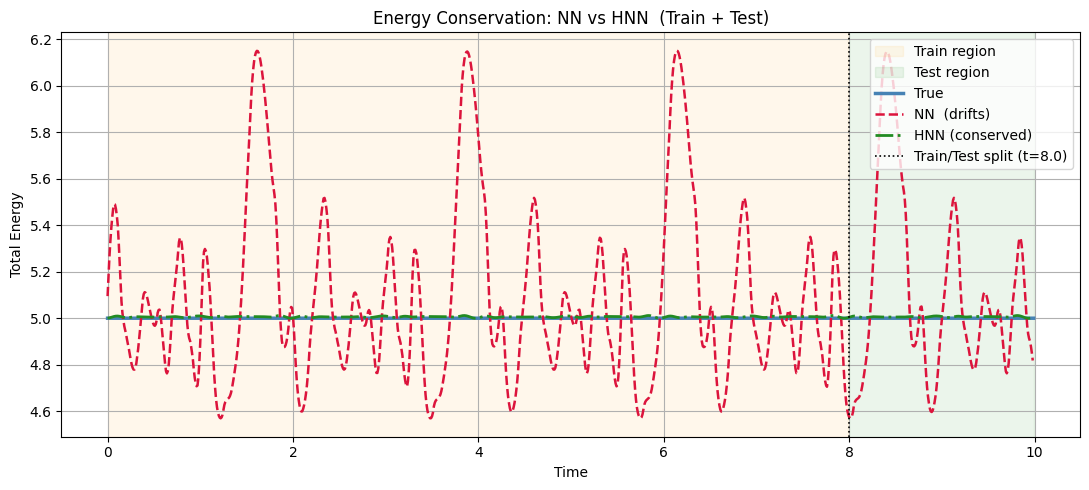

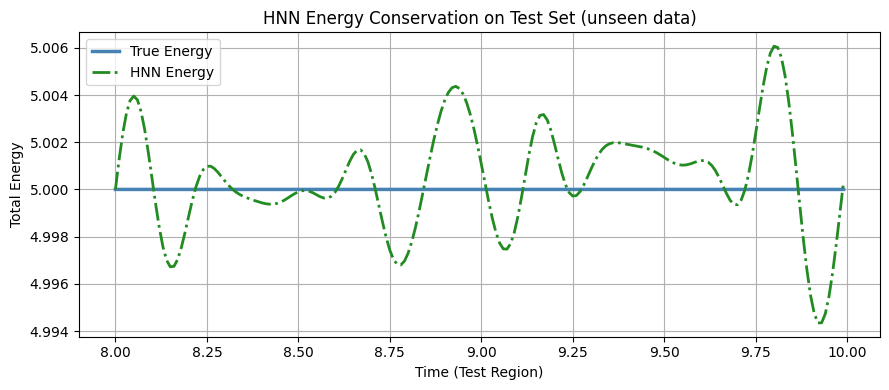

   ENERGY CONSERVATION SUMMARY
  True energy  → mean: 5.0000  std: 0.000000
  NN energy    → mean: 5.0913  std: 0.380044
  HNN energy   → mean: 5.0060  std: 0.002217
-------------------------------------------------------
  HNN test energy → mean: 5.0005  std: 0.002192


In [ ]:
# ============================================================
# HNN - ENERGY CONSERVATION  across Train and Test regions
# ============================================================

true_energy_full = 0.5 * m * qp_np[:, 1]**2       + 0.5 * k * qp_np[:, 0]**2
nn_energy_full   = 0.5 * m * traj[:, 1]**2         + 0.5 * k * traj[:, 0]**2
hnn_energy_full  = 0.5 * m * hnn_traj_full[:, 1]**2 + 0.5 * k * hnn_traj_full[:, 0]**2

# Test-region energies
true_energy_test = true_energy_full[split:]
hnn_energy_test  = 0.5 * m * hnn_traj_test[:, 1]**2 + 0.5 * k * hnn_traj_test[:, 0]**2
t_test           = t[split:]

# ── Plot 1: Full timeline ───────────────────────────────────
plt.figure(figsize=(11, 5))
plt.axvspan(t[0], t[split-1],  alpha=0.08, color='orange', label="Train region")
plt.axvspan(t[split], t[-1],   alpha=0.08, color='green',  label="Test region")
plt.plot(t,              true_energy_full,  label="True",           linewidth=2.5, color='steelblue')
plt.plot(t[:len(traj)],  nn_energy_full,    label="NN  (drifts)",   linewidth=1.8, color='crimson',     linestyle='--')
plt.plot(t,              hnn_energy_full,   label="HNN (conserved)",linewidth=2.0, color='forestgreen', linestyle='-.')
plt.axvline(t[split], color='black', linewidth=1.2, linestyle=':', label=f"Train/Test split (t={t[split]:.1f})")
plt.xlabel("Time")
plt.ylabel("Total Energy")
plt.title("Energy Conservation: NN vs HNN  (Train + Test)")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Plot 2: Test region only ────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(t_test, true_energy_test,  label="True Energy",    linewidth=2.5, color='steelblue')
plt.plot(t_test, hnn_energy_test,   label="HNN Energy",     linewidth=2.0, color='forestgreen', linestyle='-.')
plt.xlabel("Time (Test Region)")
plt.ylabel("Total Energy")
plt.title("HNN Energy Conservation on Test Set (unseen data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Summary Statistics ──────────────────────────────────────
print("=" * 55)
print("   ENERGY CONSERVATION SUMMARY")
print("=" * 55)
print(f"  True energy  → mean: {true_energy_full.mean():.4f}  std: {true_energy_full.std():.6f}")
print(f"  NN energy    → mean: {nn_energy_full.mean():.4f}  std: {nn_energy_full.std():.6f}")
print(f"  HNN energy   → mean: {hnn_energy_full.mean():.4f}  std: {hnn_energy_full.std():.6f}")
print("-" * 55)
print(f"  HNN test energy → mean: {hnn_energy_test.mean():.4f}  std: {hnn_energy_test.std():.6f}")
print("=" * 55)

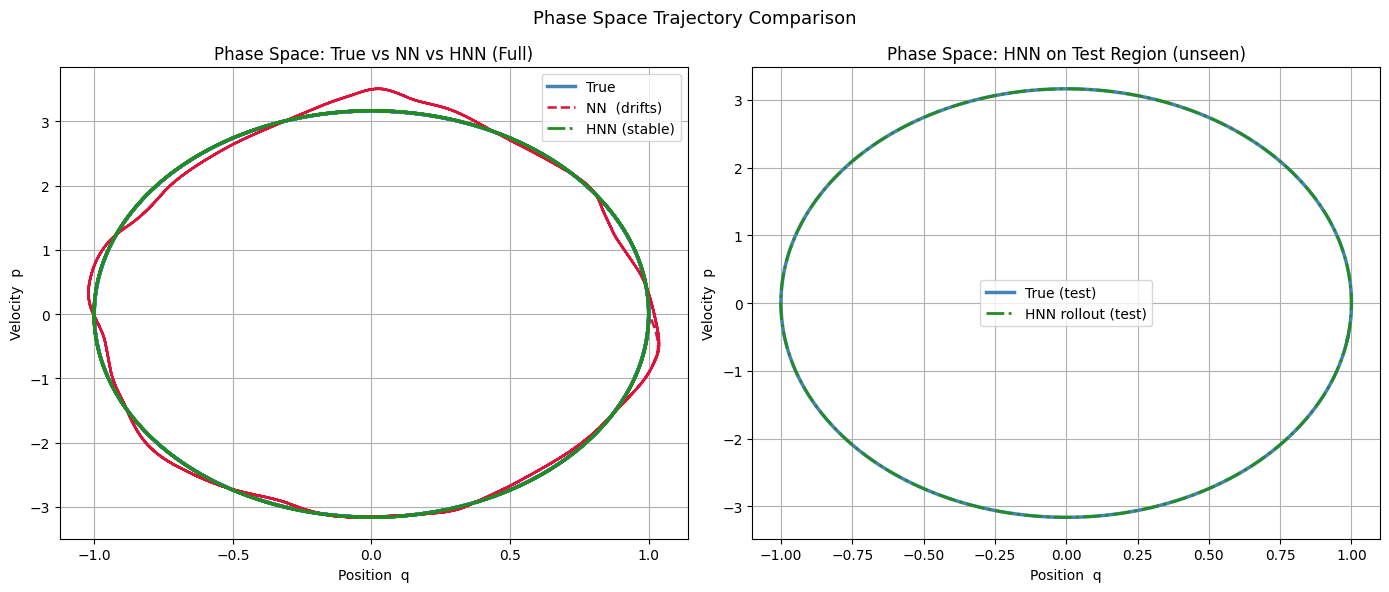

In [ ]:
# ============================================================
# HNN - PHASE SPACE TRAJECTORY  (2D)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Full trajectory comparison ────────────────────────
axes[0].plot(qp_np[:, 0],        qp_np[:, 1],        label="True",            linewidth=2.5, color='steelblue')
axes[0].plot(traj[:, 0],         traj[:, 1], '--',   label="NN  (drifts)",    linewidth=1.8, color='crimson')
axes[0].plot(hnn_traj_full[:, 0],hnn_traj_full[:, 1],'-.', label="HNN (stable)", linewidth=2.0, color='forestgreen')
axes[0].set_xlabel("Position  q")
axes[0].set_ylabel("Velocity  p")
axes[0].set_title("Phase Space: True vs NN vs HNN (Full)")
axes[0].legend()
axes[0].grid(True)

# ── Right: Test region only ──────────────────────────────────
axes[1].plot(qp_np[split:, 0],   qp_np[split:, 1],   label="True (test)",       linewidth=2.5, color='steelblue')
axes[1].plot(hnn_traj_test[:, 0],hnn_traj_test[:, 1], label="HNN rollout (test)",linewidth=2.0, color='forestgreen', linestyle='-.')
axes[1].set_xlabel("Position  q")
axes[1].set_ylabel("Velocity  p")
axes[1].set_title("Phase Space: HNN on Test Region (unseen)")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Phase Space Trajectory Comparison", fontsize=13)
plt.tight_layout()
plt.show()

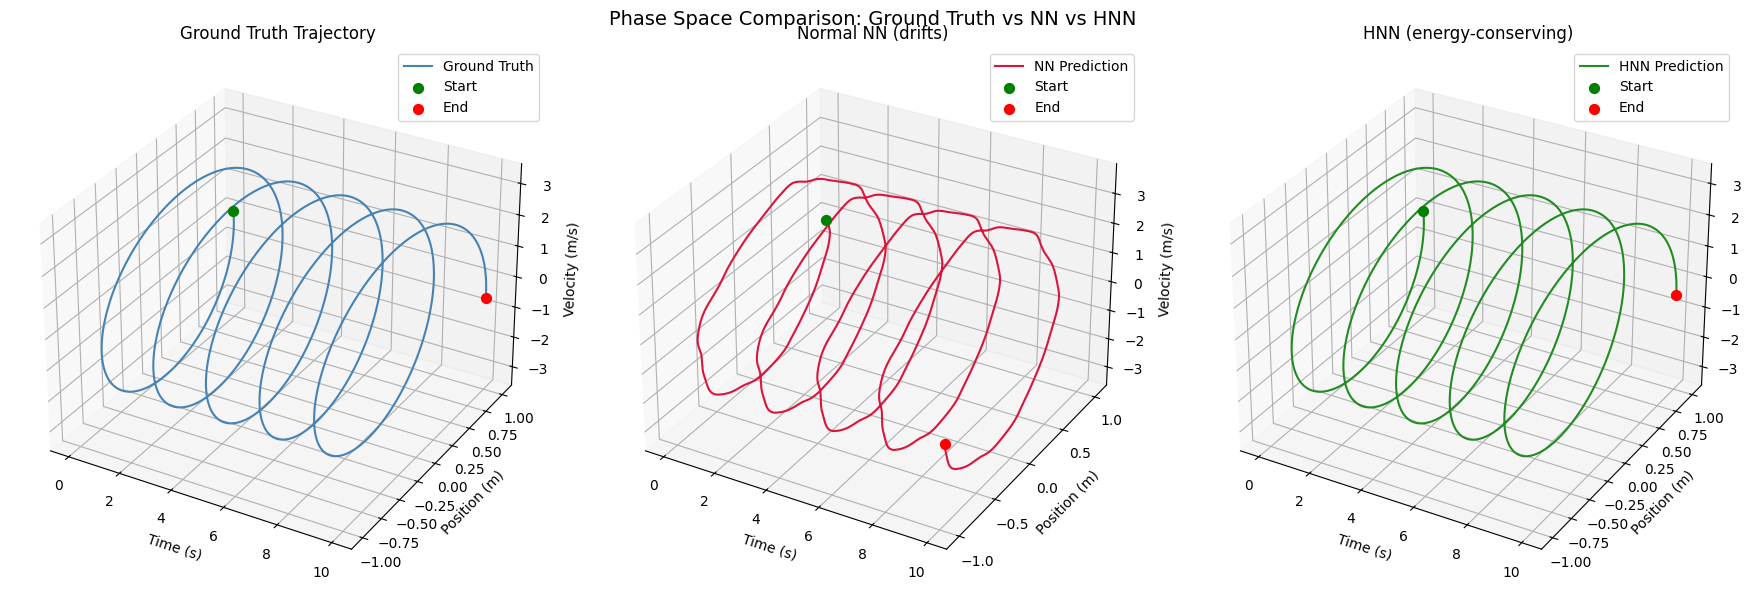

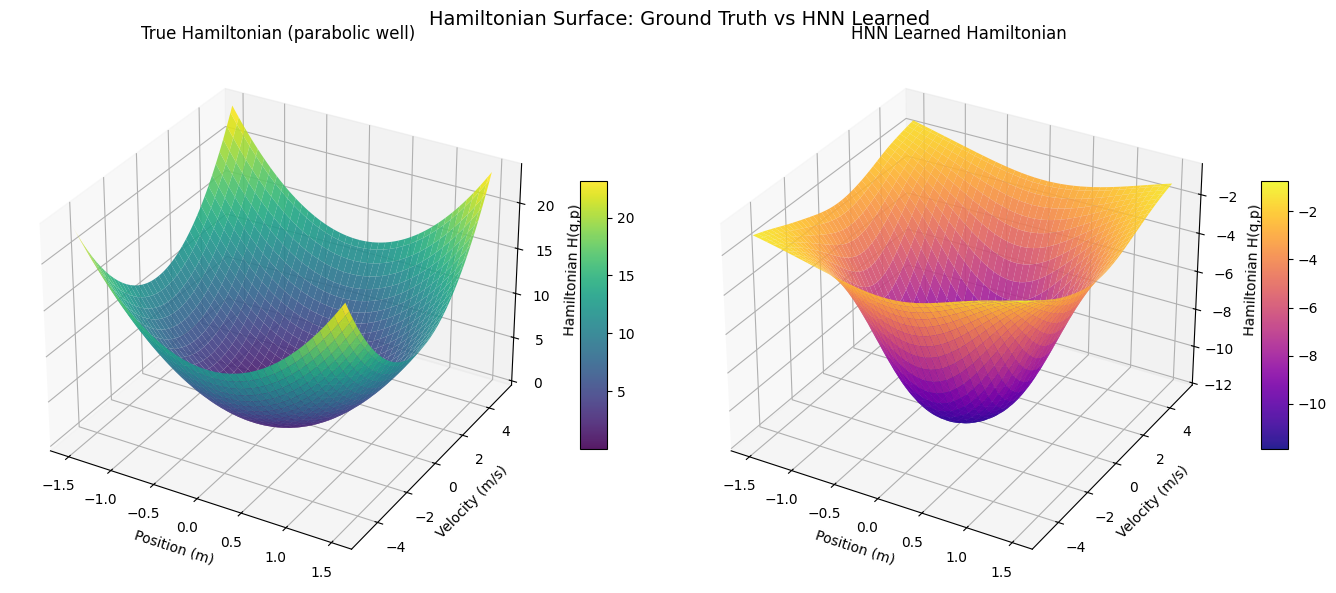

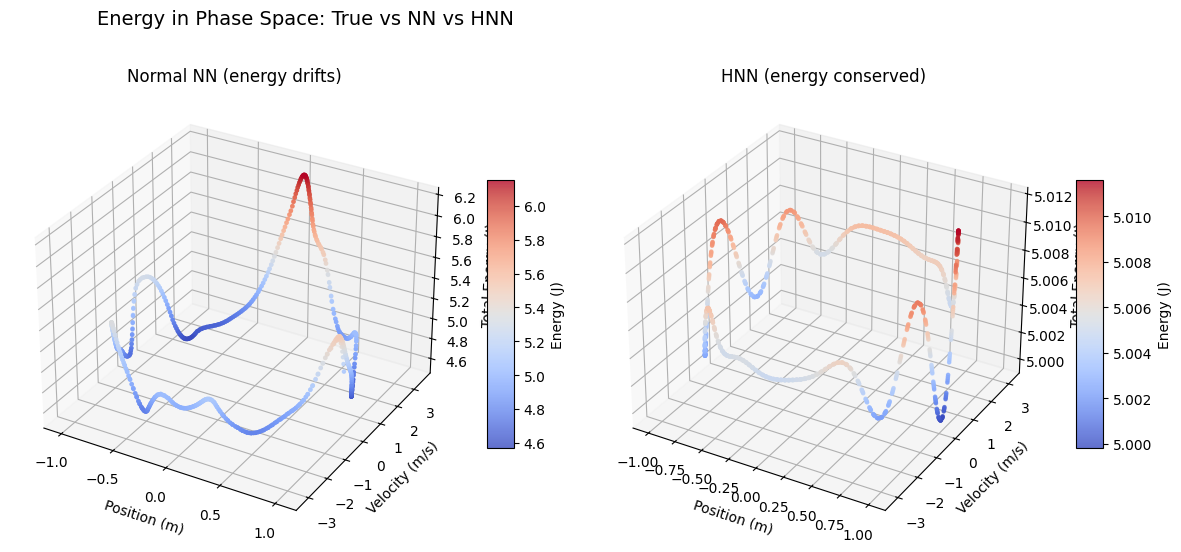

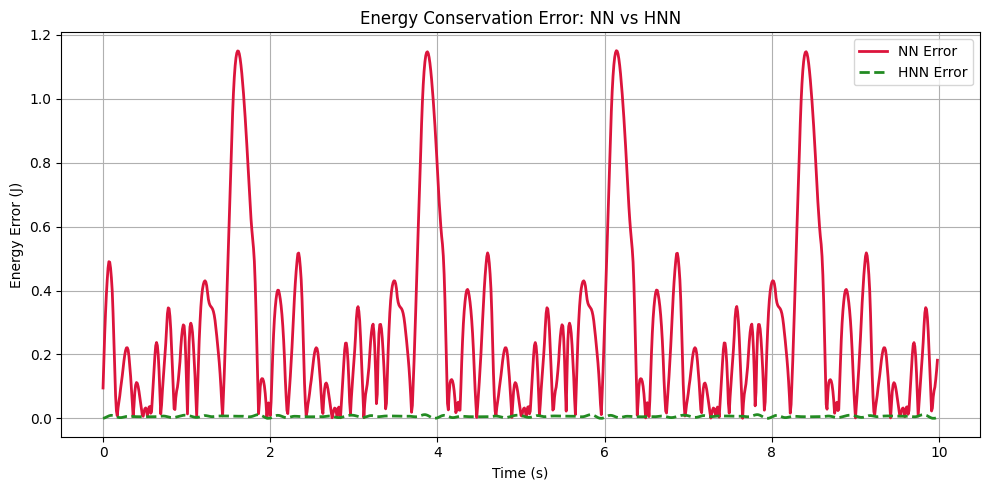

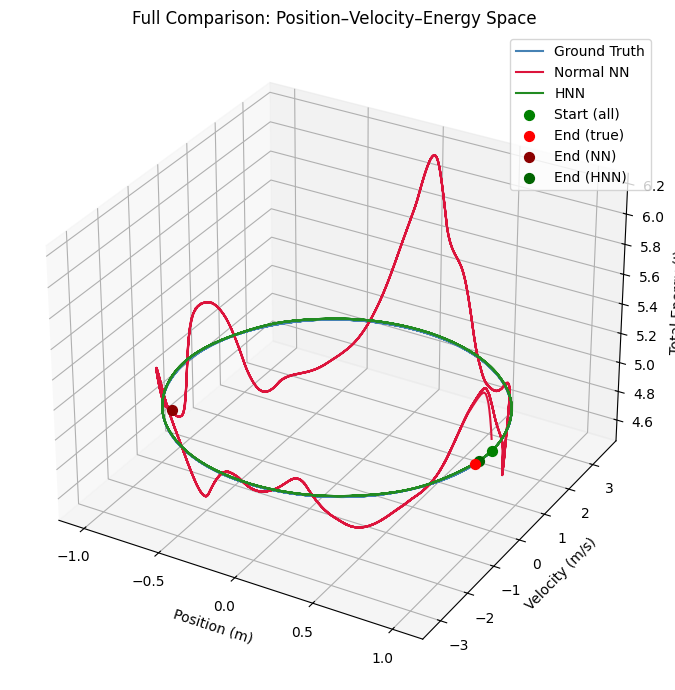


All 3D visualizations generated.
Key observations:
- Ground Truth: energy remains constant (flat plane in energy dimension).
- Normal NN: energy drifts away from true value (spirals up/down).
- HNN: energy stays nearly constant, closely following the true Hamiltonian surface.


In [ ]:
# ============================================================
# 3D VISUALIZATIONS: Ground Truth vs NN vs HNN
# Clear comparison of phase space, energy conservation, and Hamiltonian learning
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch

# ============================================================
# Helper function: Compute energies from trajectory
# ============================================================
def compute_energies(traj, m=1.0, k=10.0):
    pos = traj[:, 0]
    vel = traj[:, 1]
    kinetic = 0.5 * m * vel**2
    potential = 0.5 * k * pos**2
    total = kinetic + potential
    return kinetic, potential, total

# ============================================================
# 1. 3D Phase Space Trajectory: Time vs Position vs Velocity
# ============================================================
fig = plt.figure(figsize=(18, 6))

# Ground Truth
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot(t, x, v, color='steelblue', linewidth=1.5, label='Ground Truth')
ax1.scatter(t[0], x[0], v[0], color='green', s=50, label='Start')
ax1.scatter(t[-1], x[-1], v[-1], color='red', s=50, label='End')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position (m)')
ax1.set_zlabel('Velocity (m/s)')
ax1.set_title('Ground Truth Trajectory')
ax1.legend()

# Normal NN
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.plot(t[:len(traj)], traj[:, 0], traj[:, 1], color='crimson', linewidth=1.5, label='NN Prediction')
ax2.scatter(t[0], traj[0,0], traj[0,1], color='green', s=50, label='Start')
ax2.scatter(t[len(traj)-1], traj[-1,0], traj[-1,1], color='red', s=50, label='End')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position (m)')
ax2.set_zlabel('Velocity (m/s)')
ax2.set_title('Normal NN (drifts)')
ax2.legend()

# HNN
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.plot(t[:len(hnn_traj_full)], hnn_traj_full[:, 0], hnn_traj_full[:, 1], color='forestgreen', linewidth=1.5, label='HNN Prediction')
ax3.scatter(t[0], hnn_traj_full[0,0], hnn_traj_full[0,1], color='green', s=50, label='Start')
ax3.scatter(t[len(hnn_traj_full)-1], hnn_traj_full[-1,0], hnn_traj_full[-1,1], color='red', s=50, label='End')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Position (m)')
ax3.set_zlabel('Velocity (m/s)')
ax3.set_title('HNN (energy-conserving)')
ax3.legend()

plt.suptitle('Phase Space Comparison: Ground Truth vs NN vs HNN', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 2. 3D Energy Surface: True Hamiltonian vs HNN Learned Hamiltonian
# ============================================================
# Create grid over phase space
q_grid = np.linspace(-1.5, 1.5, 80)
p_grid = np.linspace(-5.0, 5.0, 80)
QQ, PP = np.meshgrid(q_grid, p_grid)

# True Hamiltonian: H = 0.5*k*q^2 + 0.5*p^2/m
H_true = 0.5 * k * QQ**2 + 0.5 * (PP**2) / m

# HNN learned Hamiltonian
qp_grid = torch.FloatTensor(np.stack([QQ.ravel(), PP.ravel()], axis=1))
hnn_model.eval()
with torch.no_grad():
    H_pred = hnn_model(qp_grid).numpy().reshape(80, 80)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(QQ, PP, H_true, cmap='viridis', alpha=0.9, linewidth=0, antialiased=True)
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Velocity (m/s)')
ax1.set_zlabel('Hamiltonian H(q,p)')
ax1.set_title('True Hamiltonian (parabolic well)')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(QQ, PP, H_pred, cmap='plasma', alpha=0.9, linewidth=0, antialiased=True)
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Velocity (m/s)')
ax2.set_zlabel('Hamiltonian H(q,p)')
ax2.set_title('HNN Learned Hamiltonian')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.suptitle('Hamiltonian Surface: Ground Truth vs HNN Learned', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 3. 3D Phase Space with Energy as Color
# ============================================================
# Compute energies along trajectories
# _, _, true_energy = compute_energies(qp_np, m, k)
_, _, nn_energy = compute_energies(traj, m, k)
_, _, hnn_energy = compute_energies(hnn_traj_full, m, k)

fig = plt.figure(figsize=(18, 6))

# Ground Truth
# ax1 = fig.add_subplot(1, 3, 1, projection='3d')
# sc1 = ax1.scatter(qp_np[:, 0], qp_np[:, 1], true_energy, c=true_energy, cmap='coolwarm', s=5, alpha=0.8)
# ax1.set_xlabel('Position (m)')
# ax1.set_ylabel('Velocity (m/s)')
# ax1.set_zlabel('Total Energy (J)')
# ax1.set_title('Ground Truth (constant energy)')
# fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10, label='Energy (J)')

# Normal NN
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
sc2 = ax2.scatter(traj[:, 0], traj[:, 1], nn_energy, c=nn_energy, cmap='coolwarm', s=5, alpha=0.8)
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Velocity (m/s)')
ax2.set_zlabel('Total Energy (J)')
ax2.set_title('Normal NN (energy drifts)')
fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10, label='Energy (J)')

# HNN
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
sc3 = ax3.scatter(hnn_traj_full[:, 0], hnn_traj_full[:, 1], hnn_energy, c=hnn_energy, cmap='coolwarm', s=5, alpha=0.8)
ax3.set_xlabel('Position (m)')
ax3.set_ylabel('Velocity (m/s)')
ax3.set_zlabel('Total Energy (J)')
ax3.set_title('HNN (energy conserved)')
fig.colorbar(sc3, ax=ax3, shrink=0.5, aspect=10, label='Energy (J)')

plt.suptitle('Energy in Phase Space: True vs NN vs HNN', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# # 4. 3D Energy Error Over Time (NN and HNN)
# # ============================================================
# true_energy_full = true_energy  # from above
# nn_error = np.abs(nn_energy - true_energy_full[:len(nn_energy)])
# hnn_error = np.abs(hnn_energy - true_energy_full[:len(hnn_energy)])

# fig = plt.figure(figsize=(12, 5))

# # NN error
# ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# ax1.plot(t[:len(nn_error)], nn_error, np.zeros_like(nn_error), color='crimson', linewidth=2, label='NN error')
# ax1.scatter(t[:len(nn_error)], nn_error, np.zeros_like(nn_error), c=nn_error, cmap='Reds', s=10)
# ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('Energy Error (J)')
# ax1.set_zlabel('')
# ax1.set_title('Normal NN: Energy Error over Time')
# ax1.view_init(elev=20, azim=-60)

# # HNN error
# ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# ax2.plot(t[:len(hnn_error)], hnn_error, np.zeros_like(hnn_error), color='forestgreen', linewidth=2, label='HNN error')
# ax2.scatter(t[:len(hnn_error)], hnn_error, np.zeros_like(hnn_error), c=hnn_error, cmap='Greens', s=10)
# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('Energy Error (J)')
# ax2.set_zlabel('')
# ax2.set_title('HNN: Energy Error over Time (near zero)')
# ax2.view_init(elev=20, azim=-60)

# plt.suptitle('Energy Conservation Error: NN vs HNN', fontsize=14)
# plt.tight_layout()
# plt.show()
# ============================================================
# 2D Energy Error Over Time (NN and HNN)
# ============================================================

true_energy_full = true_energy

nn_error = np.abs(nn_energy - true_energy_full[:len(nn_energy)])
hnn_error = np.abs(hnn_energy - true_energy_full[:len(hnn_energy)])

plt.figure(figsize=(10, 5))

# NN error
plt.plot(t[:len(nn_error)], nn_error,
         color='crimson', linewidth=2, label='NN Error')

# HNN error
plt.plot(t[:len(hnn_error)], hnn_error,
         color='forestgreen', linewidth=2, linestyle='--', label='HNN Error')

# Labels and styling
plt.xlabel('Time (s)')
plt.ylabel('Energy Error (J)')
plt.title('Energy Conservation Error: NN vs HNN')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 5. 3D Overlay: Ground Truth, NN, HNN in same plot with different colors
# ============================================================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectories
ax.plot(qp_np[:, 0], qp_np[:, 1], true_energy, color='steelblue', linewidth=1.5, label='Ground Truth')
ax.plot(traj[:, 0], traj[:, 1], nn_energy, color='crimson', linewidth=1.5, label='Normal NN')
ax.plot(hnn_traj_full[:, 0], hnn_traj_full[:, 1], hnn_energy, color='forestgreen', linewidth=1.5, label='HNN')

# Mark start and end points
ax.scatter(qp_np[0,0], qp_np[0,1], true_energy[0], color='green', s=50, label='Start (all)')
ax.scatter(qp_np[-1,0], qp_np[-1,1], true_energy[-1], color='red', s=50, label='End (true)')
ax.scatter(traj[-1,0], traj[-1,1], nn_energy[-1], color='darkred', s=50, label='End (NN)')
ax.scatter(hnn_traj_full[-1,0], hnn_traj_full[-1,1], hnn_energy[-1], color='darkgreen', s=50, label='End (HNN)')

ax.set_xlabel('Position (m)')
ax.set_ylabel('Velocity (m/s)')
ax.set_zlabel('Total Energy (J)')
ax.set_title('Full Comparison: Position–Velocity–Energy Space')
ax.legend()

plt.tight_layout()
plt.show()

print("\nAll 3D visualizations generated.")
print("Key observations:")
print("- Ground Truth: energy remains constant (flat plane in energy dimension).")
print("- Normal NN: energy drifts away from true value (spirals up/down).")
print("- HNN: energy stays nearly constant, closely following the true Hamiltonian surface.")